# Extracting data and plotting

These data contain temperature on the heating block of a glock 17

Sequence details

- sequence 2: 5 sequential discharges and long cool down
- sequence 3: 5 sequential discharges and long cool down

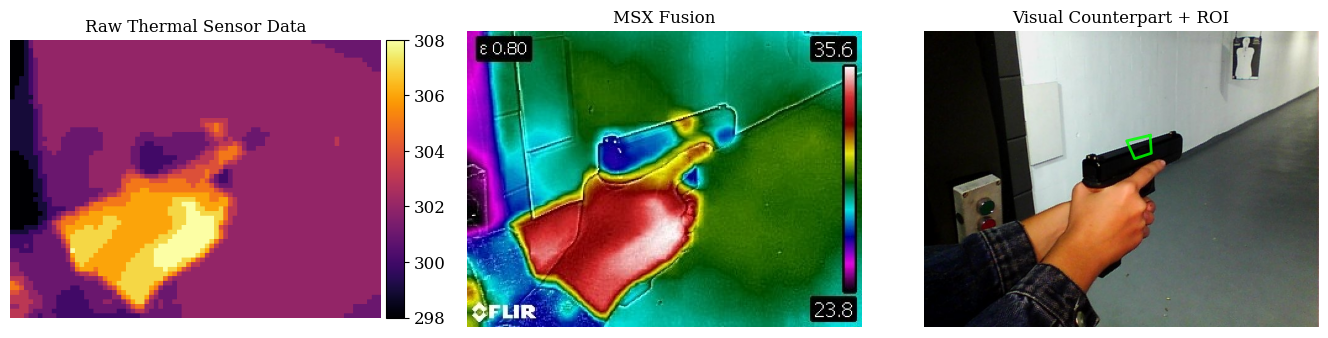

### Defining functions

In [75]:
%pip install scipy numpy pandas matplotlib scikit-learn statsmodels

Note: you may need to restart the kernel to use updated packages.


In [64]:
from scipy.optimize import curve_fit
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import json

In [74]:
def fit_plot_and_calc_frequency(seq_dir, show_outliers=False, metric='max_temperature_kelvin', min_time=0.0):
    """
    Filters thermal data, calculates mean collection frequency, 
    fits Newton's Law of Cooling, and plots the results.
    """
    seq_dir = os.path.abspath(seq_dir)
    seq_name = os.path.basename(seq_dir)
    csv_path = os.path.join(seq_dir, f"{seq_name}_timeseries.csv")

    print(f"Loading sequence: {csv_path}...")
    df = pd.read_csv(csv_path)

    # --- NEW: Filter by Minimum Time ---
    if min_time > 0:
        original_len = len(df)
        # Keep only rows where time is greater than or equal to min_time
        df = df[df['relative_time_sec'] >= min_time].copy()
        print(f"Trimmed {original_len - len(df)} frames prior to t={min_time}s")
        
        # Optional: Reset the time to start at 0 after trimming
        # df['relative_time_sec'] = df['relative_time_sec'] - min_time

    # --- 1. Filter Outliers (IQR Method) ---
    Q1 = df[metric].quantile(0.25)
    Q3 = df[metric].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df[(df[metric] >= lower_bound) & (df[metric] <= upper_bound)].copy()
    df_outliers = df[(df[metric] < lower_bound) | (df[metric] > upper_bound)].copy()

    t_clean = df_clean['relative_time_sec'].values
    temp_clean = df_clean[metric].values

    # --- 2. Calculate Mean Frequency of Filtered Data ---
    # np.diff calculates the time gap between every single consecutive frame
    dt_array = np.diff(t_clean) 
    
    if len(dt_array) > 0:
        mean_dt = np.mean(dt_array)
        mean_freq = 1.0 / mean_dt # Frequency (Hz) is 1 over the time period
    else:
        mean_dt = 0
        mean_freq = 0

    # --- 3. Fit the Exponential Decay (Newton's Law) ---
    def thermal_decay(t, A, k, C):
        return A * np.exp(-k * t) + C

    guess_C = np.min(temp_clean)                     
    guess_A = np.max(temp_clean) - guess_C           
    guess_k = 0.01                                   
    p0 = [guess_A, guess_k, guess_C]

    bounds = ([0, 0, 0], [np.inf, np.inf, np.inf])

    try:
        popt, pcov = curve_fit(thermal_decay, t_clean, temp_clean, p0=p0, bounds=bounds)
        A_fit, k_fit, C_fit = popt

        t_smooth = np.linspace(df['relative_time_sec'].min(), df['relative_time_sec'].max(), 500)
        temp_pred_smooth = thermal_decay(t_smooth, *popt)
        
        temp_pred_clean = thermal_decay(t_clean, *popt)
        r_squared = r2_score(temp_clean, temp_pred_clean)

        # --- NEW: Calculate Residuals and Variance ---
        residuals = temp_clean - temp_pred_clean
        # ddof=3 accounts for the 3 parameters estimated by the model (A, k, C)
        residual_variance = np.var(residuals, ddof=3)

        # --- NEW: Augmented Dickey-Fuller Stationarity Test ---
        # autolag='AIC' lets the function automatically choose the optimal number of lags
        adf_result = adfuller(residuals, autolag='AIC') 
        adf_statistic = adf_result[0]
        adf_pvalue = adf_result[1]

        # Determine stationarity based on a 5% significance level
        is_stationary = "Yes" if adf_pvalue < 0.05 else "No"

        print(f"\n--- Data Collection Statistics ---")
        print(f"Original Frames: {len(df)}")
        print(f"Clean Frames Retained: {len(df_clean)}")
        print(f"Mean Time Step (\u0394t): {mean_dt:.4f} seconds")
        print(f"Mean Effective Frequency: {mean_freq:.4f} Hz")

        print(f"\n--- Exponential Decay Fit Results ---")
        print(f"Equation: T(t) = {A_fit:.2f} * e^(-{k_fit:.5f} * t) + {C_fit:.2f}")
        print(f"R-squared: {r_squared:.4f}\n")
        print(f"Residual Variance: {residual_variance:.4f}\n")

        # --- NEW: Print ADF Results ---
        print(f"\n--- Residual Stationarity (ADF Test) ---")
        print(f"Test Statistic: {adf_statistic:.4f}")
        print(f"P-value: {adf_pvalue:.4e}")
        print(f"Stationary (p < 0.05): {is_stationary}\n")

        # --- 4. Plotting (Publication Ready) ---
        # Set global parameters for cleaner typography
        plt.rcParams.update({
            'font.size': 14,
            'font.family': 'serif', # Matches most academic text
            'axes.labelsize': 16,
            'xtick.labelsize': 12,
            'ytick.labelsize': 12,
            'legend.fontsize': 12,
        })

        # Use a dimension better suited for standard paper columns (e.g., 8x6 or 7x5)
        fig, ax = plt.subplots(figsize=(12, 4))

        # Plot Data - Deep blue for data, clean edges
        ax.scatter(t_clean, temp_clean, color='#00429d', alpha=0.5, s=30, 
                   edgecolors='none', label='Clean Data')
        
        if show_outliers and not df_outliers.empty:
            ax.scatter(df_outliers['relative_time_sec'], df_outliers[metric], 
                       color='#737373', marker='x', alpha=0.8, s=20, label='Outliers')

        # Plot Curve Fit - Dark contrasting line
        ax.plot(t_smooth, temp_pred_smooth, color='#93003a', linewidth=2, 
                 label=f'Decay Fit ($R^2={r_squared:.2f}$)')

        # Labels (Clean standard abbreviations)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Max Temperature (K)")
        
        # NOTE: Titles are omitted. Put descriptions in your LaTeX/Word figure caption.

        # Tufte principles: Remove unnecessary borders
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Subtle grid (optional, but keep it quiet if used)
        ax.grid(True, linestyle=':', alpha=0.4, color='gray')

        # Clean up the info text formatting
        info_text = (f"$\\Delta t_{{mean}}$: {mean_dt:.3f} s\n"
                     f"Effective frequency: {mean_freq:.2f} Hz\n"
                     f"Residual Variance: {residual_variance:.2f}\n"
                     f"Stationarity (ADF): {is_stationary}")
        
        # Move the text box to the middle-right to avoid clashing with the legend
        ax.text(0.95, 0.6, info_text, transform=ax.transAxes, 
                 verticalalignment='center', horizontalalignment='right',
                 bbox=dict(boxstyle='square,pad=0.5', facecolor='white', alpha=0.9, edgecolor='none'))

        # Clean legend without a heavy frame
        ax.legend(loc='upper right', frameon=False)
        
        plt.tight_layout()
        
        # Save high-res vector and raster formats automatically
        plot_filename_pdf = os.path.join(seq_dir, f"{seq_name}_decay_plot.pdf")
        plot_filename_png = os.path.join(seq_dir, f"{seq_name}_decay_plot.png")
        plt.savefig(plot_filename_pdf, format='pdf', bbox_inches='tight')
        plt.savefig(plot_filename_png, dpi=300, bbox_inches='tight')
        
        plt.show()

    except RuntimeError as e:
        print(f"Curve fitting failed to converge: {e}")

def plot_heat_distribution_histogram(seq_dir, target_time=0.0, bins=50):
    """
    Reads a CSV, finds the frame closest to target_time, extracts and parses 
    the heat_distribution_json, and plots it as a clean, publication-ready histogram.
    """
    seq_dir = os.path.abspath(seq_dir)
    seq_name = os.path.basename(seq_dir)
    csv_path = os.path.join(seq_dir, f"{seq_name}_timeseries.csv")

    print(f"Loading sequence: {csv_path}...")
    df = pd.read_csv(csv_path)

    # --- 1. Find the target frame ---
    # Find the row where relative_time_sec is closest to our target_time
    closest_idx = (df['relative_time_sec'] - target_time).abs().idxmin()
    target_row = df.loc[closest_idx]
    actual_time = target_row['relative_time_sec']
    
    print(f"Target time requested: {target_time}s")
    print(f"Extracting distribution from closest frame at t={actual_time:.3f}s")

    # --- 2. Parse the JSON Distribution ---
    try:
        raw_json = target_row['heat_distribution_json']
        # Parse the JSON string into a Python list
        temp_data = json.loads(raw_json)
        
        # Convert to numpy array and flatten (in case the JSON stored a 2D spatial array)
        temp_array = np.array(temp_data).flatten()
        
        # Optional: Remove any NaN or infinite values that might break the histogram
        temp_array = temp_array[np.isfinite(temp_array)]
        
    except (json.JSONDecodeError, KeyError, TypeError) as e:
        print(f"Failed to parse 'heat_distribution_json' at t={actual_time}s: {e}")
        return

    # --- 3. Plotting (Publication Ready) ---
    # Match global parameters exactly to the time-series plot
    plt.rcParams.update({
        'font.size': 14,
        'font.family': 'serif', 
        'axes.labelsize': 16,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12,
    })

    # A slightly more square aspect ratio often looks better for histograms 
    # than the wide 12x4, but we'll stick to a clean 8x5 for standard columns.
    fig, ax = plt.subplots(figsize=(8, 5))

    # Plot Histogram - Using the same deep blue, with a thin white edge to separate bins
    counts, edges, patches = ax.hist(
        temp_array, 
        bins=bins, 
        color='#00429d', 
        alpha=0.85, 
        edgecolor='white', 
        linewidth=0.5,
        label=f't = {actual_time:.2f}s'
    )

    # Mean and Median lines (Often useful in thermal distributions)
    mean_temp = np.mean(temp_array)
    median_temp = np.median(temp_array)
    
    # Using the contrasting dark red from your previous plot for the mean indicator
    ax.axvline(mean_temp, color='#93003a', linestyle='--', linewidth=2, label=f'Mean ({mean_temp:.1f} K)')
    ax.axvline(median_temp, color='#737373', linestyle=':', linewidth=2, label=f'Median ({median_temp:.1f} K)')

    # Labels
    ax.set_xlabel("Temperature (K)")
    ax.set_ylabel("Pixel Count (Frequency)")

    # Tufte principles: Remove unnecessary borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Subtle horizontal-only grid to help read bin heights without cluttering
    ax.grid(axis='y', linestyle=':', alpha=0.4, color='gray')
    ax.grid(axis='x', visible=False)

    # Clean legend
    ax.legend(loc='upper right', frameon=False)
    
    plt.tight_layout()
    
    # Save high-res vector and raster formats automatically
    # Appending the time to the filename so you can generate multiple without overwriting
    time_str = f"{actual_time:.1f}".replace('.', 'p')
    plot_filename_pdf = os.path.join(seq_dir, f"{seq_name}_hist_t{time_str}.pdf")
    plot_filename_png = os.path.join(seq_dir, f"{seq_name}_hist_t{time_str}.png")
    
    plt.savefig(plot_filename_pdf, format='pdf', bbox_inches='tight')
    plt.savefig(plot_filename_png, dpi=300, bbox_inches='tight')
    
    plt.show()

    print(f"Plots saved as:\n - {plot_filename_pdf}\n - {plot_filename_png}")
    print(f"Distribution Stats: Min={np.min(temp_array):.2f}K, Max={np.max(temp_array):.2f}K, StdDev={np.std(temp_array):.2f}K")

### Loading and plotting time series

Loading sequence: /home/oestequeda/Desktop/Workstation/PFN_pewpew_analytics/data/sequence_2/sequence_2_timeseries.csv...
Trimmed 3 frames prior to t=20s

--- Data Collection Statistics ---
Original Frames: 24
Clean Frames Retained: 23
Mean Time Step (Δt): 3.9091 seconds
Mean Effective Frequency: 0.2558 Hz

--- Exponential Decay Fit Results ---
Equation: T(t) = 6.40 * e^(-0.03719 * t) + 304.25
R-squared: 0.8693

Residual Variance: 0.0530


--- Residual Stationarity (ADF Test) ---
Test Statistic: -3.4714
P-value: 8.7530e-03
Stationary (p < 0.05): Yes



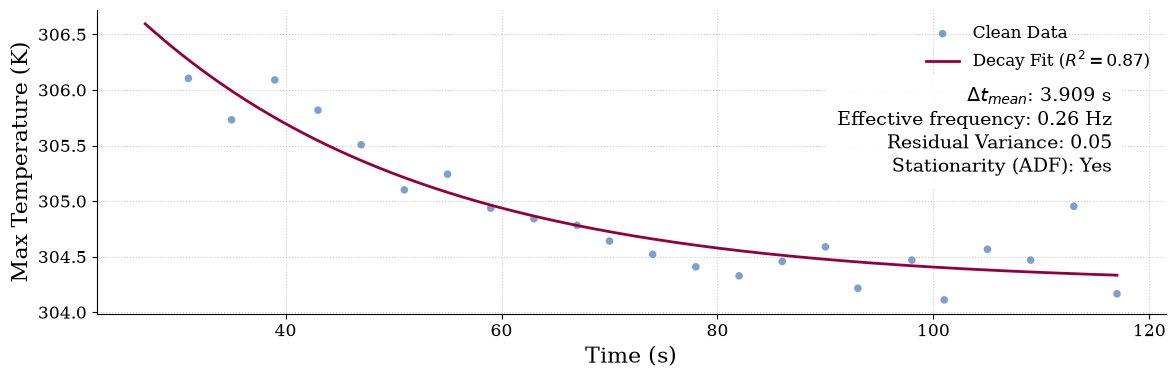

Loading sequence: /home/oestequeda/Desktop/Workstation/PFN_pewpew_analytics/data/sequence_2/sequence_2_timeseries.csv...
Target time requested: 20.0s
Extracting distribution from closest frame at t=18.000s


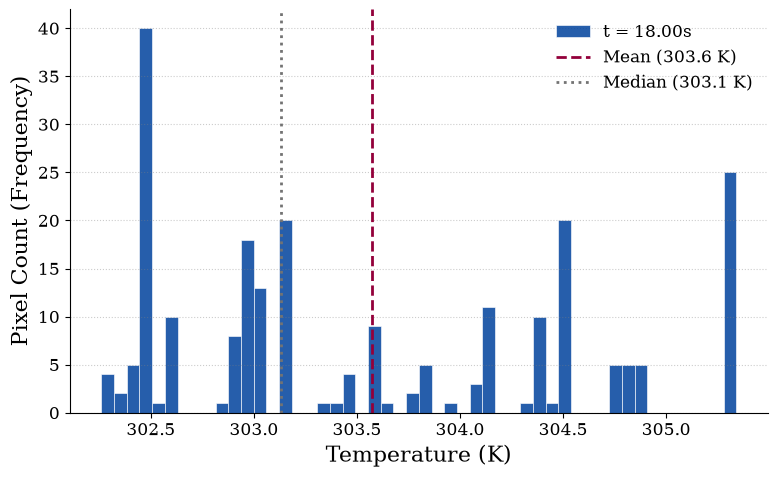

Plots saved as:
 - /home/oestequeda/Desktop/Workstation/PFN_pewpew_analytics/data/sequence_2/sequence_2_hist_t18p0.pdf
 - /home/oestequeda/Desktop/Workstation/PFN_pewpew_analytics/data/sequence_2/sequence_2_hist_t18p0.png
Distribution Stats: Min=302.26K, Max=305.34K, StdDev=0.98K


In [73]:
seq_dir = "./data/sequence_2"
fit_plot_and_calc_frequency(seq_dir, show_outliers=False, min_time=20)#, metric='peak_mean_temperature_kelvin')
plot_heat_distribution_histogram(seq_dir, target_time=20.0, bins=50)

Loading sequence: /home/oestequeda/Desktop/Workstation/PFN_pewpew_analytics/data/sequence_3/sequence_3_timeseries.csv...
Trimmed 2 frames prior to t=20s

--- Data Collection Statistics ---
Original Frames: 22
Clean Frames Retained: 19
Mean Time Step (Δt): 4.7778 seconds
Mean Effective Frequency: 0.2093 Hz

--- Exponential Decay Fit Results ---
Equation: T(t) = 3.10 * e^(-0.03113 * t) + 304.14
R-squared: 0.8449

Residual Variance: 0.0488


--- Residual Stationarity (ADF Test) ---
Test Statistic: -4.0795
P-value: 1.0468e-03
Stationary (p < 0.05): Yes



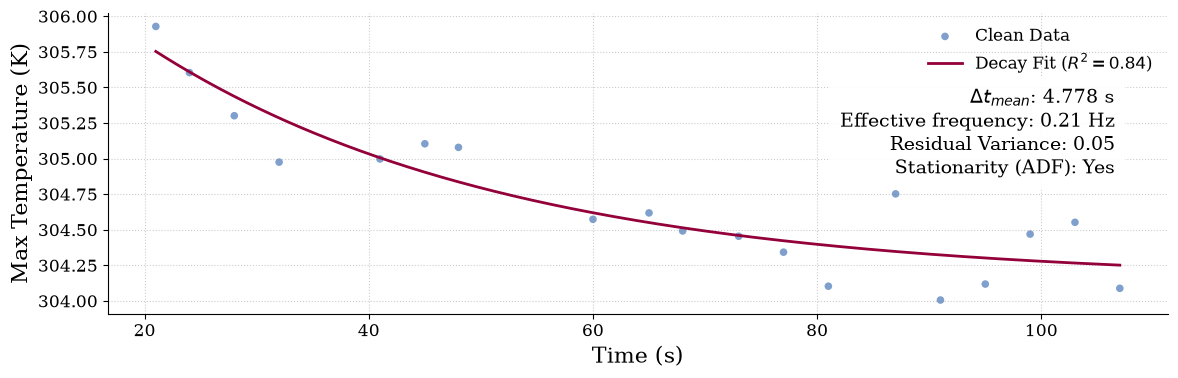

Loading sequence: /home/oestequeda/Desktop/Workstation/PFN_pewpew_analytics/data/sequence_3/sequence_3_timeseries.csv...
Target time requested: 20.0s
Extracting distribution from closest frame at t=21.000s


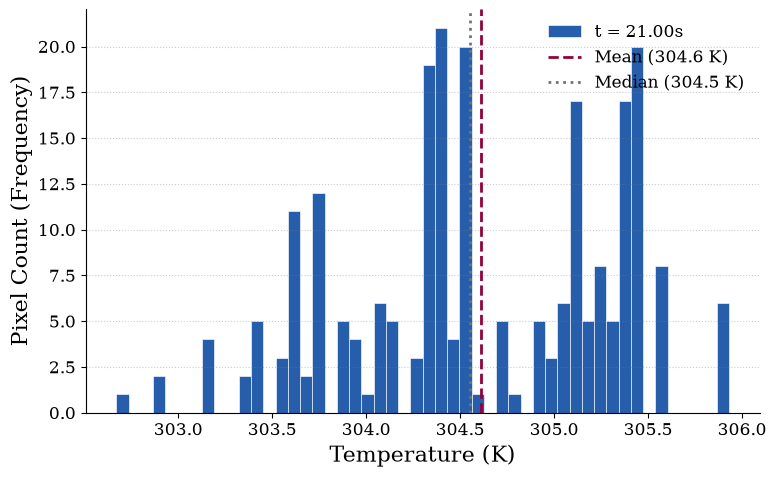

Plots saved as:
 - /home/oestequeda/Desktop/Workstation/PFN_pewpew_analytics/data/sequence_3/sequence_3_hist_t21p0.pdf
 - /home/oestequeda/Desktop/Workstation/PFN_pewpew_analytics/data/sequence_3/sequence_3_hist_t21p0.png
Distribution Stats: Min=302.67K, Max=305.93K, StdDev=0.71K


In [72]:
seq_dir = "./data/sequence_3"
fit_plot_and_calc_frequency(seq_dir, show_outliers=False, min_time=20)#, metric='peak_mean_temperature_kelvin')
plot_heat_distribution_histogram(seq_dir, target_time=20.0, bins=50)